Para cada dígito 𝑑 = 0,1, … ,9 selecciona aleatoriamente 𝑘 imágenes de entrenamiento. Esto
dará para cada dígito una matriz de datos de tamaño 𝑘 × 64

In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import numpy as np

# --- 1. Cargar datos y partir en train/test ---
digits = load_digits()
X = digits.images
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
K = 14
print("X_train shape:", X_train.shape)

X_train shape: (1257, 8, 8)


In [4]:
rng = np.random.default_rng(123)
imagenesXDijito = {}
for d in range(10):
    indices_d = np.where(y_train == d)[0]
    seleccion = rng.choice(indices_d, size=K, replace=False)
    imagenesXDijito[d] = X_train[seleccion]
print("Ejemplo imagenesXDijito[3].shape:", imagenesXDijito[3].shape)

Ejemplo imagenesXDijito[3].shape: (14, 8, 8)


Convierta cada imagen a una matriz. Luego, recorta la imagen para eliminar las filas y
columnas con únicamente el fondo (de modo que se preserve la mayor parte del dígito). 

In [5]:
def recortar_fondo(img, umbral=1):
    """img: matriz 2D (8x8). Valores <= umbral se consideran fondo."""
    mascara = img > umbral
    if not mascara.any():
        return img
    filas_validas = np.where(mascara.any(axis=1))[0]
    columnas_validas = np.where(mascara.any(axis=0))[0]
    fila_min, fila_max = filas_validas[0], filas_validas[-1]
    col_min, col_max = columnas_validas[0], columnas_validas[-1]
    return img[fila_min : fila_max + 1, col_min : col_max + 1]

imagenes_recortadas = {}
for d in range(10):
    imgs = imagenesXDijito[d]
    imagenes_recortadas[d] = [recortar_fondo(img) for img in imgs]
print("Ejemplo imagen recortada dígito 3, img 0:", imagenes_recortadas[3][0].shape)

Ejemplo imagen recortada dígito 3, img 0: (8, 6)


Luego reescala la imagen resultante a un tamaño fijo de 16 × 16 píxeles.

In [6]:
from skimage.transform import resize

def pad_a_cuadrada(img):
    h, w = img.shape
    L = max(h, w)
    nueva = np.zeros((L, L))
    top = (L - h) // 2
    left = (L - w) // 2
    nueva[top : top + h, left : left + w] = img
    return nueva

imagenes_16x16 = {}
for d in range(10):
    procesadas = []
    for img in imagenes_recortadas[d]:
        img_cuadrada = pad_a_cuadrada(img)
        img_redimensionada = resize(img_cuadrada, (16, 16), preserve_range=True)
        procesadas.append(img_redimensionada)
    imagenes_16x16[d] = procesadas
print("Ejemplo imagenes_16x16[3][0].shape:", np.array(imagenes_16x16[3][0]).shape)



Ejemplo imagenes_16x16[3][0].shape: (16, 16)


Finalmente,
convierta cada imagen reescalada a un vector de longitud 256

In [7]:
def matriz_16x16_a_vector(img):
    return img.reshape(256)

vectores_256 = {}
for d in range(10):
    arr = np.array(imagenes_16x16[d])
    vectores_256[d] = arr.reshape(len(arr), 256)
print("vectores_256[3].shape:", vectores_256[3].shape)

# --- 6. Matrices de datos k×256 y Md (256×K) ---
matrices = {}
for d in range(10):
    arr = np.array(imagenes_16x16[d])
    matrices[d] = arr.reshape(K, 256)

Md = {}
for d in range(10):
    Md[d] = matrices[d].T
print("Md[3].shape:", Md[3].shape)


vectores_256[3].shape: (14, 256)
Md[3].shape: (256, 14)


Comparativa visual: original, recortada, reescalada

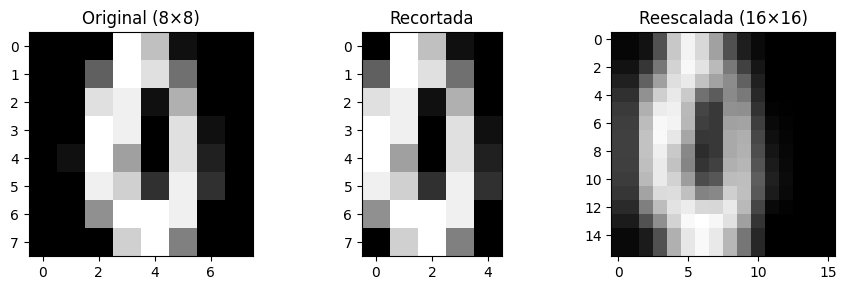

In [8]:
import matplotlib.pyplot as plt

img_original = X_train[0]
img_rec = recortar_fondo(img_original)
img_cuad = pad_a_cuadrada(img_rec)
img_rees = resize(img_cuad, (16,16), preserve_range=True)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].set_title("Original (8×8)")
ax[0].imshow(img_original, cmap="gray")
ax[1].set_title("Recortada")
ax[1].imshow(img_rec, cmap="gray")
ax[2].set_title("Reescalada (16×16)")
ax[2].imshow(img_rees, cmap="gray")
plt.tight_layout()
plt.show()

Para cada dígito d: organizar los k vectores en una matriz M_d (cada columna = una imagen) ---
Cada vector tiene 256 componentes. M_d es de tamaño 256×k (filas = píxeles, columnas = imágenes).

In [9]:
Md = {}
for d in range(10):
    # k vectores de 256 componentes → apilar como columnas → matriz (256, k)
    vectores_d = vectores_256[d]   # shape (k, 256)
    Md[d] = vectores_d.T           # shape (256, k): columna j = imagen j del dígito d
print("Para cada dígito d, M_d tiene forma (256, k): cada columna es una imagen.")
print("Ejemplo M_3.shape:", Md[3].shape, "→ 256 filas (píxeles),", Md[3].shape[1], "columnas (imágenes)")

Para cada dígito d, M_d tiene forma (256, k): cada columna es una imagen.
Ejemplo M_3.shape: (256, 14) → 256 filas (píxeles), 14 columnas (imágenes)


Para cada dígito calcule una base ortonormal del espacio vectorial generado por las columnas
de 𝑀𝑑, denotemos a esa base 𝐵𝑑 que la vamos a construir usando la matriz 𝑈𝑑 resultantes de
la Descomposición en Valores Singulares

In [10]:
Ud = {}
sd = {}
Vhd = {}
Bd = {}
for d in range(10):
    Ud[d], sd[d], Vhd[d] = np.linalg.svd(Md[d], full_matrices=False)
    
    Bd[d] = Ud[d]
print("Base ortonormal B_d: columnas de U_d (SVD de M_d).")
print("Ejemplo B_3.shape:", Bd[3].shape, "→ 256 filas,", Bd[3].shape[1], "vectores ortonormales")

print("Comprobación ortonormalidad B_3 (B_3.T @ B_3 ≈ I): max error =", np.max(np.abs(Bd[3].T @ Bd[3] - np.eye(Bd[3].shape[1]))))

Base ortonormal B_d: columnas de U_d (SVD de M_d).
Ejemplo B_3.shape: (256, 14) → 256 filas, 14 vectores ortonormales
Comprobación ortonormalidad B_3 (B_3.T @ B_3 ≈ I): max error = 1.9984014443252818e-15


magen de prueba: mismo proceso → vector q de longitud 256 ---
Tomar una imagen del conjunto de prueba (no está en entrenamiento)

In [11]:
idx_prueba = 0  # puede cambiar a otro índice de X_test
img_prueba_original = X_test[idx_prueba]
etiqueta_real = y_test[idx_prueba]

# Mismo proceso: recortar → reescalar 16×16 → vector q
img_prueba_recortada = recortar_fondo(img_prueba_original)
img_prueba_cuadrada = pad_a_cuadrada(img_prueba_recortada)
img_prueba_16x16 = resize(img_prueba_cuadrada, (16, 16), preserve_range=True)
q = img_prueba_16x16.reshape(256)

print("Imagen de prueba (índice", idx_prueba, "en X_test), etiqueta real:", etiqueta_real)
print("q.shape:", q.shape, "→ vector de 256 componentes")

Imagen de prueba (índice 0 en X_test), etiqueta real: 1
q.shape: (256,) → vector de 256 componentes


royección ortogonal de q sobre B_d, distancia dist(q,d) y clasificación ---
 p_d = proyección de q sobre el subespacio generado por B_d. Como B_d es ortonormal: p_d = B_d @ (B_d.T @ q)
 dist(q, d) = ||q - p_d||. Clasificar asignando el dígito d que minimiza dist(q, d)

In [12]:
pd = {}
dist_q_d = {}
for d in range(10):
    pd[d] = Bd[d] @ (Bd[d].T @ q)
    dist_q_d[d] = np.linalg.norm(q - pd[d])

etiqueta_predicha = np.argmin([dist_q_d[d] for d in range(10)])
print("\nDistancias dist(q, d) por dígito d:", [round(dist_q_d[d], 4) for d in range(10)])
print("Etiqueta predicha (d que minimiza dist(q,d)):", etiqueta_predicha)
print("Etiqueta real:", etiqueta_real)
print("¿Coincide?", etiqueta_predicha == etiqueta_real)



Distancias dist(q, d) por dígito d: [np.float64(57.4735), np.float64(12.5825), np.float64(27.8946), np.float64(56.7317), np.float64(51.435), np.float64(56.3652), np.float64(47.5228), np.float64(77.2604), np.float64(45.799), np.float64(52.6912)]
Etiqueta predicha (d que minimiza dist(q,d)): 1
Etiqueta real: 1
¿Coincide? True


In [13]:
n_eval = 50
rng_eval = np.random.default_rng(42)
indices_eval = rng_eval.choice(len(X_test), size=n_eval, replace=False)

aciertos = 0
for idx in indices_eval:
    img_orig = X_test[idx]
    img_rec = recortar_fondo(img_orig)
    img_cua = pad_a_cuadrada(img_rec)
    img_16 = resize(img_cua, (16, 16), preserve_range=True)
    q_eval = img_16.reshape(256)
    # dist(q_eval, d) = ||q_eval - p_d|| con p_d = B_d @ (B_d.T @ q_eval)
    distancias = [np.linalg.norm(q_eval - Bd[d] @ (Bd[d].T @ q_eval)) for d in range(10)]
    pred = np.argmin(distancias)
    if pred == y_test[idx]:
        aciertos += 1

porcentaje_aciertos = 100 * aciertos / n_eval
print("\n--- Evaluación en 50 imágenes de prueba (no usadas en M_d) ---")
print("Aciertos:", aciertos, "/", n_eval)
print("Porcentaje de aciertos: {:.1f}%".format(porcentaje_aciertos))


--- Evaluación en 50 imágenes de prueba (no usadas en M_d) ---
Aciertos: 45 / 50
Porcentaje de aciertos: 90.0%


In [14]:

# --- Variar k y graficar precisión en función de k ---
valores_k = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 25, 30, 40, 50]
rng = np.random.default_rng(123)
rng_eval = np.random.default_rng(42)
indices_eval_graf = rng_eval.choice(len(X_test), size=n_eval, replace=False)

precisiones = []
for k in valores_k:
    imagenesXDijito = {}
    for d in range(10):
        indices_d = np.where(y_train == d)[0]
        seleccion = rng.choice(indices_d, size=k, replace=False)
        imagenesXDijito[d] = X_train[seleccion]

    imagenes_recortadas = {}
    for d in range(10):
        imagenes_recortadas[d] = [recortar_fondo(img) for img in imagenesXDijito[d]]

    imagenes_16x16 = {}
    for d in range(10):
        procesadas = []
        for img in imagenes_recortadas[d]:
            img_cuadrada = pad_a_cuadrada(img)
            img_redimensionada = resize(img_cuadrada, (16, 16), preserve_range=True)
            procesadas.append(img_redimensionada)
        imagenes_16x16[d] = procesadas

    vectores_256 = {}
    for d in range(10):
        arr = np.array(imagenes_16x16[d])
        vectores_256[d] = arr.reshape(len(arr), 256)

    Md = {}
    for d in range(10):
        vectores_d = vectores_256[d]
        Md[d] = vectores_d.T

    Bd = {}
    for d in range(10):
        Ud[d], sd[d], Vhd[d] = np.linalg.svd(Md[d], full_matrices=False)
        Bd[d] = Ud[d]

    aciertos = 0
    for idx in indices_eval_graf:
        img_orig = X_test[idx]
        img_rec = recortar_fondo(img_orig)
        img_cua = pad_a_cuadrada(img_rec)
        img_16 = resize(img_cua, (16, 16), preserve_range=True)
        q_eval = img_16.reshape(256)
        distancias = [np.linalg.norm(q_eval - Bd[d] @ (Bd[d].T @ q_eval)) for d in range(10)]
        pred = np.argmin(distancias)
        if pred == y_test[idx]:
            aciertos += 1
    precisiones.append(100 * aciertos / n_eval)
    print("k = {:3d}  →  Precisión: {:.1f}%".format(k, precisiones[-1]))

k =   2  →  Precisión: 78.0%
k =   4  →  Precisión: 84.0%
k =   6  →  Precisión: 88.0%
k =   8  →  Precisión: 86.0%
k =  10  →  Precisión: 84.0%
k =  12  →  Precisión: 86.0%
k =  14  →  Precisión: 86.0%
k =  16  →  Precisión: 92.0%
k =  18  →  Precisión: 86.0%
k =  20  →  Precisión: 90.0%
k =  25  →  Precisión: 96.0%
k =  30  →  Precisión: 94.0%
k =  40  →  Precisión: 80.0%
k =  50  →  Precisión: 70.0%
